# Bulk RNA-seq differential expression

PyDESeq2 analysis of rice salt stress (E-MTAB-1625)

Here we analyse the transcriptional response of rice seedlings to salt
stress. Counts and sample annotations come from Expression Atlas
experiment E-MTAB-1625; [PyDESeq2](https://pydeseq2.readthedocs.io/)
provides the differential-expression model, while ggnomics is used for
quality control, PCA, and results visualization.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("_includes").resolve()))
from setup import configure_warnings, ensure_matplotlib_initialized
ensure_matplotlib_initialized()  # see the import-order note in _includes/setup.py
configure_warnings()

import numpy as np
import pandas as pd
import ggnomics as gg
from plotnine import theme_bw, theme, labs, element_text

## 1. Study and design

- **Accession**:
  [E-MTAB-1625](https://www.ebi.ac.uk/gxa/experiments/E-MTAB-1625)
  (EMBL-EBI Expression Atlas, via `pyexpressionatlas`)
- **Organism**: *Oryza sativa* Japonica Group (rice)
- **Biological question**: transcriptional response of 2-week-old rice
  seedlings to 300 mM NaCl salt stress, sampled at 1, 5, and 24 hours
- **Data used here**: 38,866 genes x 18 shoot samples with raw integer
  counts
- **Count assay**: `"counts"` (raw), genes x samples orientation
- **Metadata fields used**: `growth condition` (2 levels), `time` (3
  levels)

## 2. Loading and inspecting the experiment

In [2]:
from data import load_emtab1625

se = load_emtab1625()
se.shape

Package 'multiassayexperiment' is not installed.

(38866, 18)

In [3]:
se.get_assay_names()

['counts']

In [4]:
cd = se.get_column_data().to_pandas()
cd[["growth condition", "time"]]

The cross-tabulation confirms a balanced 2 x 3 design with three
replicates for each condition and time point:

In [5]:
pd.crosstab(cd["growth condition"], cd["time"])

## 3. Library size and count-distribution QC

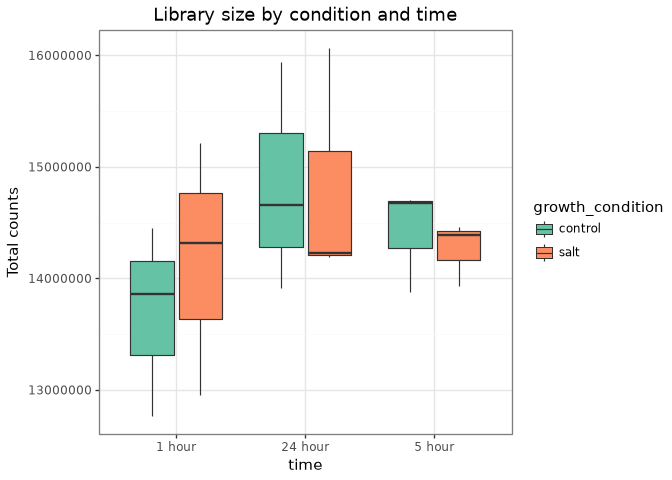

In [6]:
counts_raw = np.asarray(se.get_assay("counts"))
lib_sizes = pd.DataFrame({
    "sample": se.get_column_names(),
    "library_size": counts_raw.sum(axis=0),
    "growth_condition": cd["growth condition"].map({
        "300 millimolar sodium chloride": "salt", "normal watering": "control",
    }).to_numpy(),
    "time": cd["time"].to_numpy(),
})
gg.plot_coldata(lib_sizes, x="time", y="library_size", color_by="growth_condition", shape="box") + theme_bw() + labs(title="Library size by condition and time", y="Total counts")

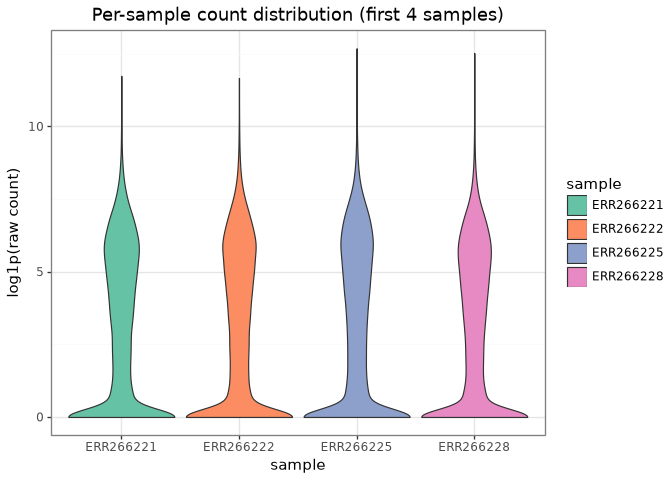

In [7]:
gene_names = se.get_row_names()
log_counts_long = pd.DataFrame(
    np.log1p(counts_raw[:, :4]), columns=se.get_column_names()[:4]
).melt(var_name="sample", value_name="log1p_count")
gg.plot_coldata(log_counts_long, x="sample", y="log1p_count", shape="violin") + theme_bw() + labs(title="Per-sample count distribution (first 4 samples)", y="log1p(raw count)")

## 4. Selecting an estimable, replicated contrast

All three time points support a matched salt-versus-control comparison.
We use the 24-hour samples to examine the sustained response: three
salt-treated and three control samples, with
`design = ~growth_condition`, reference level `"control"`, and contrast
`["growth_condition", "salt", "control"]`.

In [8]:
sel_cd = cd.copy()
sel_cd["growth_condition"] = sel_cd["growth condition"].map({
    "300 millimolar sodium chloride": "salt", "normal watering": "control",
})
sel_cd["time"] = sel_cd["time"].str.replace(" ", "_")
sub_cd = sel_cd.loc[sel_cd["time"] == "24_hour"]
sub_cd[["growth_condition"]]

## 5. Fitting PyDESeq2 on raw integer counts

In [9]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

counts_df = pd.DataFrame(counts_raw, index=gene_names, columns=se.get_column_names()).T
counts_df = counts_df.loc[sub_cd.index].round().astype(int)  # raw integer counts, gene-by-sample transposed to sample-by-gene

metadata = sub_cd[["growth_condition"]].copy()
metadata["growth_condition"] = pd.Categorical(metadata["growth_condition"], categories=["control", "salt"])

dds = DeseqDataSet(counts=counts_df, metadata=metadata, design="~growth_condition", refit_cooks=True, quiet=True)
dds.deseq2()

In [10]:
ds = DeseqStats(dds, contrast=["growth_condition", "salt", "control"], alpha=0.05, quiet=True)
ds.summary()
results = ds.results_df
results.shape

(38866, 6)

In [11]:
(results["padj"] < 0.05).sum()

np.int64(832)

## 6. Variance-stabilizing transformation — for visualization only

The Wald test above uses the raw counts together with DESeq2’s
size-factor and dispersion model. Variance-stabilized values are
calculated separately for PCA and heatmaps, where reducing the
dependence of variance on the mean makes sample structure easier to
visualize:

In [12]:
dds.vst_fit()
vst = pd.DataFrame(dds.vst_transform(), index=counts_df.index, columns=counts_df.columns)
vst.iloc[:, :5].head()

The helper `run_deseq2_on_emtab1625()` caches the fitted model and
transformed expression matrix so they can be reused by the other
examples:

In [13]:
from data import run_deseq2_on_emtab1625

fit = run_deseq2_on_emtab1625()
results, vst, metadata = fit["results"], fit["vst"], fit["metadata"]

## 7. PCA on the VST-transformed expression

`ggnomics.bulk_pca` computes PCA from an assay in a
`SummarizedExperiment`. In contrast, the top-level `ggnomics.plot_pca`
visualizes coordinates that have already been computed. The single-cell
counterpart is shown in the [scranpy workflow](single-cell-scranpy.ipynb).

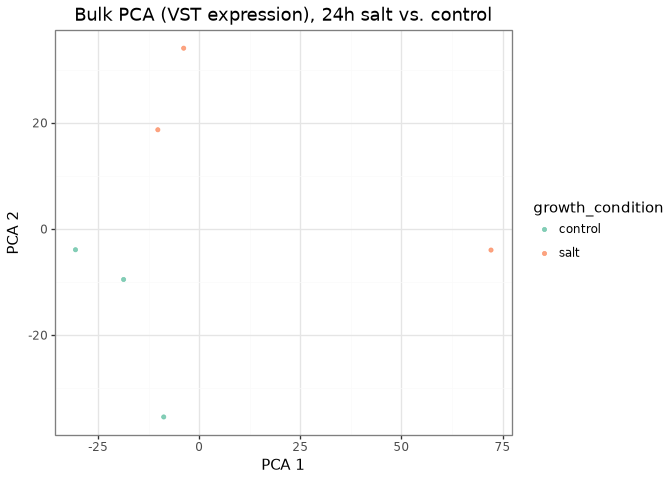

In [14]:
from summarizedexperiment import SummarizedExperiment

vst_se = SummarizedExperiment(
    assays={"vst": vst.T.to_numpy()},  # genes x samples
    row_data=pd.DataFrame(index=vst.columns),
    column_data=metadata,
)
gg.bulk_pca.plot_pca(vst_se, assay_name="vst", color="growth_condition", n_components=5) + theme_bw() + labs(title="Bulk PCA (VST expression), 24h salt vs. control")

## 8. Volcano and MA plots

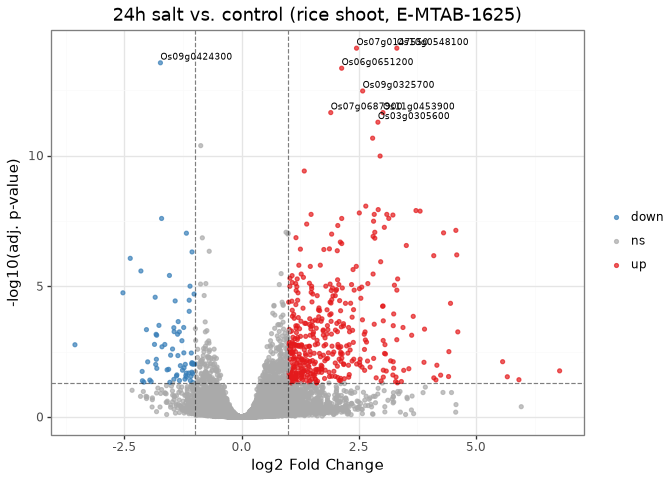

In [15]:
gg.plot_volcano(results, label_top_n=8) + theme_bw() + labs(title="24h salt vs. control (rice shoot, E-MTAB-1625)")

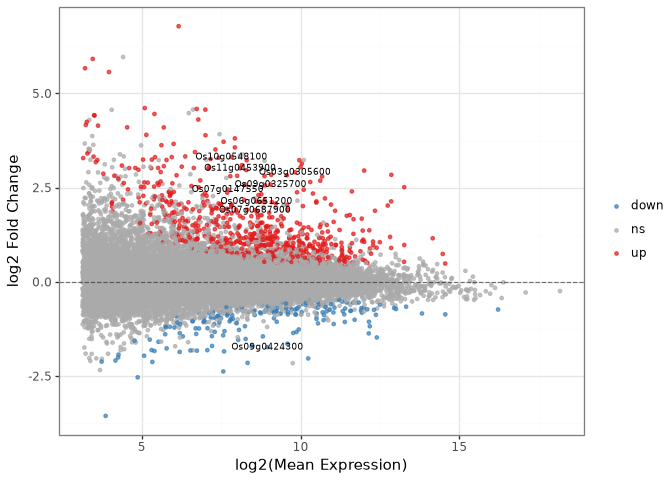

In [16]:
gg.plot_ma(results, label_top_n=8) + theme_bw()

## 9. Coefficient (lollipop) plot

`plot_coef_lollipop` can rank and display the per-gene `log2FoldChange`
coefficients returned by PyDESeq2:

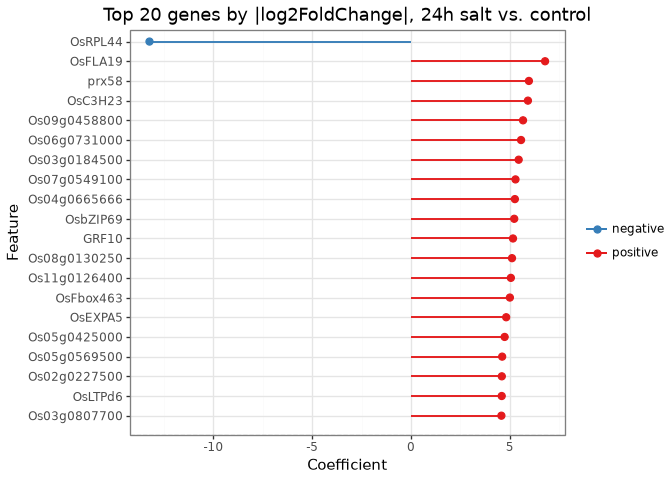

In [17]:
top_genes = results.reindex(results["log2FoldChange"].abs().sort_values(ascending=False).index).head(20)
coefs = top_genes[["log2FoldChange"]].rename(columns={"log2FoldChange": "coefficient"})
gene_label_map = fit["gene_names"]
coefs.index = [gene_label_map.get(g) or g for g in coefs.index]
gg.plot_coef_lollipop(coefs, top_n=20) + theme_bw() + labs(title="Top 20 genes by |log2FoldChange|, 24h salt vs. control")

## 10. Heatmap of top differentially expressed genes

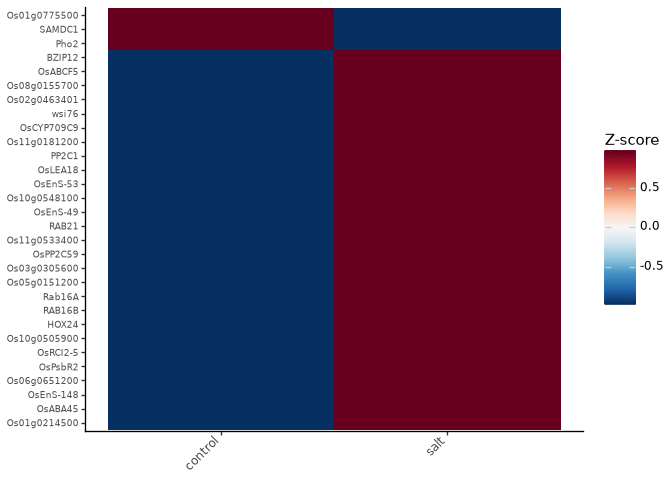

In [18]:
sig_top = results.loc[results["padj"] < 0.05].sort_values("padj").head(30)
heat_df = vst[sig_top.index].copy()
heat_df.columns = [gene_label_map.get(g) or g for g in heat_df.columns]
heat_df["growth_condition"] = metadata["growth_condition"].to_numpy()

gg.plot_heatmap(
    heat_df, features=list(heat_df.columns[:-1]), group_by="growth_condition",
    cluster_rows=True, cluster_cols=True,
) + theme(axis_text_x=element_text(rotation=45, hjust=1))

## 11. Extending the returned objects

The volcano and MA plots can be combined directly with plotnine’s
composition operators:

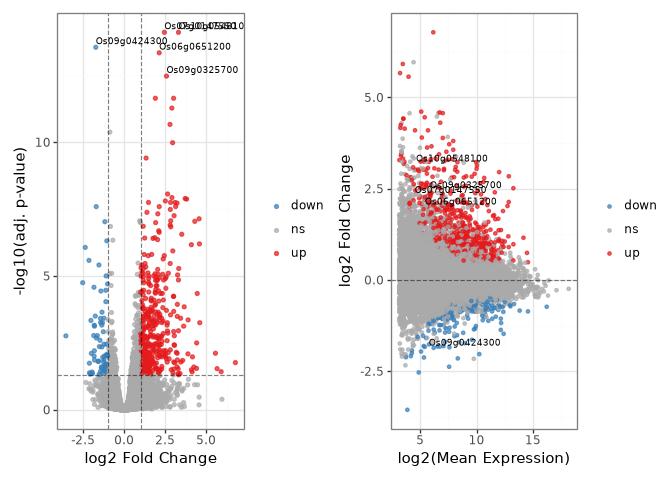

In [19]:
volcano = gg.plot_volcano(results, label_top_n=5) + theme_bw()
ma = gg.plot_ma(results, label_top_n=5) + theme_bw()
volcano | ma

## Next

- [UpSet plots](upset.ipynb) compares the significant/top-ranked DE genes
  across the three E-MTAB-1625 timepoints (1, 5, and 24 hours) fitted
  here.
- [Specialized plots](specialized-plots.ipynb) uses the cached fit for
  additional volcano, MA, lollipop, and heatmap examples.
- [Single-cell analysis with scranpy](single-cell-scranpy.ipynb) for the
  single-cell analogue of this workflow.